C:\Users\felpp\AppData\Local\Temp\ipykernel_30708\3476585523.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  treino_df['Age'].fillna(treino_df['Age'].median(), inplace=True)
C:\Users\felpp\AppData\Local\Temp\ipykernel_30708\3476585523.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

Resultados da Avaliação dos Modelos:
                    Acurácia  Precisão    Recall  F1-Score
Naive Bayes        0.782123  0.727273  0.695652  0.711111
Árvore de Decisão  0.821229  0.793651  0.724638  0.757576
SVM                0.776536  0.737705  0.652174  0.692308
Rede Neural        0.782123  0.734375  0.681159  0.706767

Resultados do Melhor Modelo no Conjunto de Teste:
                Acurácia  Precisão    Recall  F1-Score
Melhor Modelo  0.782297  0.672316  0.782895  0.723404


<Figure size 1200x600 with 0 Axes>

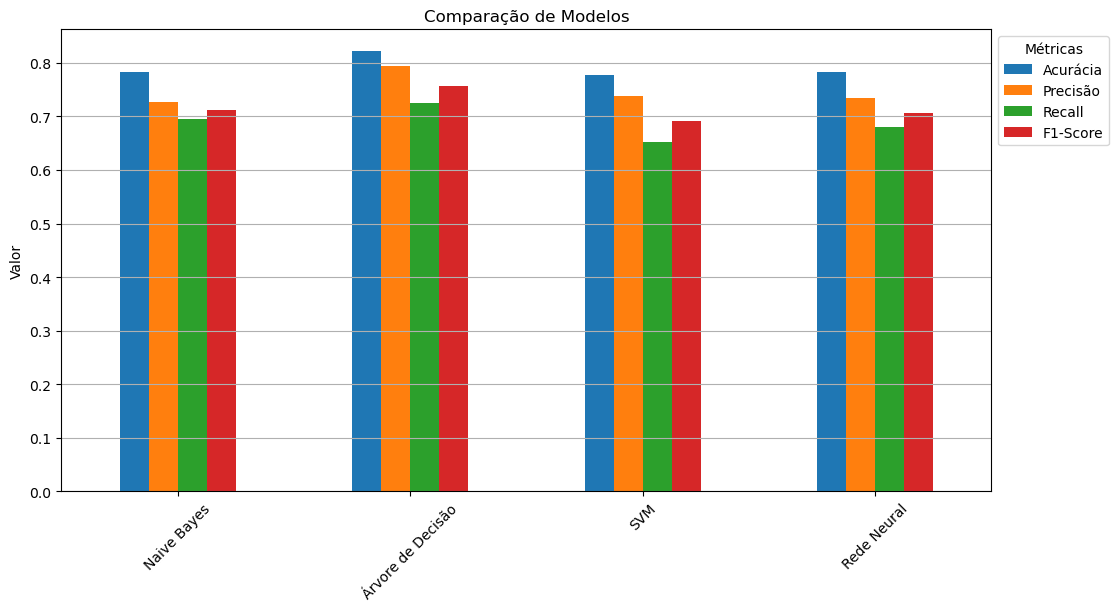

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Carregar os dados
treino = "C:\\Users\\felpp\\Downloads\\titanic\\train.csv"
teste = "C:\\Users\\felpp\\Downloads\\titanic\\test.csv"
gabarito = "C:\\Users\\felpp\\Downloads\\titanic\\gender_submission.csv"

treino_df = pd.read_csv(treino)
teste_df = pd.read_csv(teste)
gabarito_df = pd.read_csv(gabarito)

# Tratamento de dados ausentes
treino_df['Age'].fillna(treino_df['Age'].median(), inplace=True)
teste_df['Age'].fillna(teste_df['Age'].median(), inplace=True)
treino_df['Embarked'].fillna(treino_df['Embarked'].mode()[0], inplace=True)
teste_df['Embarked'].fillna(teste_df['Embarked'].mode()[0], inplace=True)
teste_df['Fare'].fillna(teste_df['Fare'].median(), inplace=True)

# Remover colunas irrelevantes
treino_df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'], inplace=True)
teste_df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'], inplace=True)

# Codificação de variáveis categóricas
treino_df['Sex'] = treino_df['Sex'].map({'female': 0, 'male': 1})
teste_df['Sex'] = teste_df['Sex'].map({'female': 0, 'male': 1})
treino_df = pd.get_dummies(treino_df, columns=['Embarked'], drop_first=True)
teste_df = pd.get_dummies(teste_df, columns=['Embarked'], drop_first=True)

# Separar variáveis preditoras e alvo
X = treino_df.drop(columns=['Survived'])
y = treino_df['Survived']

# Dividir dados em treino e validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Função para treinar e avaliar modelos
def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return {
        'Acurácia': accuracy_score(y_val, y_pred),
        'Precisão': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred)
    }

# Modelos
models = {
    "Naive Bayes": GaussianNB(),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel="linear", random_state=42),
    "Rede Neural": MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
}

# Avaliação dos modelos
results = {name: evaluate_model(model, name) for name, model in models.items()}
results_df = pd.DataFrame(results).T

# Treinar o melhor modelo (Árvore de Decisão) com todos os dados
best_model = DecisionTreeClassifier(random_state=42)
best_model.fit(X, y)

# Fazer previsões no conjunto de teste
y_test_pred = best_model.predict(teste_df)

gabarito_survived = gabarito_df["Survived"].values

# Calcular métricas finais
final_results = {
    "Acurácia": accuracy_score(gabarito_survived, y_test_pred),
    "Precisão": precision_score(gabarito_survived, y_test_pred),
    "Recall": recall_score(gabarito_survived, y_test_pred),
    "F1-Score": f1_score(gabarito_survived, y_test_pred)
}
final_results_df = pd.DataFrame(final_results, index=["Melhor Modelo"])

# Exibir resultados
print("Resultados da Avaliação dos Modelos:\n", results_df)
print("\nResultados do Melhor Modelo no Conjunto de Teste:\n", final_results_df)

# Usar results_df para criar o DataFrame de comparação
comparison_df = results_df.copy()

# Criar gráfico comparativo
plt.figure(figsize=(12, 6))
comparison_df.plot(kind="bar", figsize=(12, 6))
plt.title("Comparação de Modelos")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.legend(title="Métricas", bbox_to_anchor=(1, 1))
plt.grid(axis="y")
plt.show()